In [8]:
# Install and import necessary NLP, machine learning, and visualization libraries
!pip install nltk pandas scikit-learn matplotlib seaborn -q
import nltk
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Set plotting style
sns.set_theme(style="whitegrid")
print("Libraries, dependencies, and visualization tools loaded successfully!")

Libraries, dependencies, and visualization tools loaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
# Create an expanded sample news dataset (40 samples: 20 Real, 20 Fake)
data = {
    'Article_ID': [f'N{i:02d}' for i in range(1, 41)],
    'Title': [
        'Global Climate Summit Reaches Landmark Agreement',
        'Miracle Cure Discovered That Cures All Diseases Overnight',
        'Central Bank Announces New Interest Rates for Next Quarter',
        'Aliens Confirmed Living Inside Government Secret Facility',
        'Tech Giant Releases New Eco-Friendly Smartphone Series',
        'Drinking Tap Water Turns People into Robots Instantly',
        'Stock Markets Close Higher Following Positive Job Reports',
        'Secret Society Controls Global Weather Patterns from Antarctica',
        'New Renewable Energy Grid Launched in Western Europe',
        'Eat Chocolate Every Day to Lose 30 Pounds in One Week',
        'NASA Rover Discovers Ancient Riverbed on Mars',
        'Ancient Pharoah Curse Causes Local Traffic Jam in Chicago',
        'Global Supply Chain Stabilization Shows Positive Recovery',
        'Time Travel Device Invented by Local High School Student',
        'Medical Researchers Develop New Vaccine for Malaria',
        'Billionaire Buys the Moon and Claims Real Estate Rights',
        'Education Ministry Introduces Digital Literacy Programs',
        'Flying Cars Now Mandatory for Commuters Starting Next Month',
        'Major Cybersecurity Framework Adopted by Financial Institutions',
        'Invisible Cloak Tech Sold at Local Discount Supermarket',
        'Global Renewable Energy Investments Hit Record High in 2026',
        'Moon Cheese Confirmed Real by Astronaut Secret Mission',
        'International Trade Agreement Signed by Ten Major Economies',
        'Teleportation Booths Installed in New York Subway Stations',
        'World Health Organization Releases Updated Pandemic Guidelines',
        'Mermaid Spotted Swimming Near Statue of Liberty',
        'National Infrastructure Bill Approved by Senate Committee',
        'Pigeons Operate Underground Spy Network Across Capitals',
        'Agricultural Output Increases Due to Smart Farming Technologies',
        'Gravity Reversed for Two Hours in Small Australian Town',
        'Space Agency Successfully Launches Next-Gen Weather Satellite',
        'Cloud Computing Company Moves Data Centers to Planet Mars',
        'Automotive Sector Transitions Rapidly to Electric Fleet Production',
        'Ancient Dragon Egg Hatched in Local Suburban Backyard',
        'Marine Biologists Discover New Coral Reef Species in Pacific',
        'Vampire Clan Demands Equal Tax Representation in Parliament',
        'Economic Growth Projections Revised Upward for Fiscal Year',
        'Unicorn Sighted Grazing Near Central Park Meadows',
        'Global Cybersecurity Coalition Neutralizes Major Ransomware Threat',
        'Ghosts Form Labor Union to Demand Better Haunting Conditions'
    ],
    'Text': [
        "World leaders met in Geneva today to sign a historic climate agreement focusing on reducing carbon emissions by 2030 through renewable energy investments.",
        "Doctors hate this one weird trick! A local man discovered an ancient herbal tea that completely eliminates cancer, diabetes, and aging in 24 hours.",
        "The Federal Reserve announced a modest 0.25% adjustment to benchmark interest rates following steady employment growth figures released this morning.",
        "A whistleblower leaked classified documents claiming extraterrestrial beings have been operating a subterranean base beneath a federal installation since 1985.",
        "Apple announced its latest smartphone lineup featuring 100% recycled aluminum casings, improved battery life, and extended software support.",
        "Scientists warn that municipal tap water systems are being laced with microchips designed to control human behavior and thought patterns.",
        "Wall Street indices finished the trading session in positive territory driven by stronger-than-expected retail sales and robust employment data.",
        "Satellite imagery reveals massive underground generators operated by an elite cabal changing storm tracks across the Northern Hemisphere.",
        "European nations successfully integrated a cross-border smart grid powered entirely by wind and solar farms.",
        "Nutritionists are baffled as consuming 500 grams of dark chocolate daily melts fat effortlessly without exercise.",
        "The Perseverance rover transmitted high-resolution images confirming ancient liquid water flows inside Jezero Crater.",
        "Commuters were stuck for hours after a bizarre municipal rumor sparked supernatural panic across downtown intersections.",
        "International shipping indexes report container turnaround times have normalized back to pre-pandemic benchmarks.",
        "A teenager built a functioning temporal displacement engine in his parents garage using household electronics.",
        "Clinical trials confirm a new dual-action vaccine successfully prevents malaria transmission in high-risk regions.",
        "A tech entrepreneur filed paperwork with international courts claiming sole proprietary title over lunar soil.",
        "Schools across the district will integrate mandatory coding and digital safety modules starting next semester.",
        "Municipal authorities announced flying vehicles will replace standard lanes on major highways by autumn.",
        "Banking regulators finalized cybersecurity compliance frameworks requiring mandatory threat-sharing protocols.",
        "Bargain shoppers rushed to local outlets after flyers advertised military-grade invisibility fabric for under twenty dollars.",
        "Global investments in solar and wind power surpassed traditional fossil fuels for the third consecutive year according to energy reports.",
        "A classified Apollo mission report supposedly revealed that lunar surface craters are filled with edible cheddar cheese.",
        "Trade ministers concluded multi-lateral tariff negotiations aimed at boosting cross-border digital commerce.",
        "Commuters can now instantly teleport across boroughs using experimental quantum booths installed at major transit hubs.",
        "The WHO published comprehensive guidelines on strengthening healthcare supply chains against future biological disruptions.",
        "Bystanders captured blurry footage of what they claim was a mythical mermaid lounging near New York harbor.",
        "The Senate passed a bipartisan bill allocating billions toward modernizing bridges, tunnels, and public transit grids.",
        "Ornithologists joke as conspiracy theorists claim city pigeons are covertly transmitting classified surveillance data.",
        "Precision agriculture sensors and automated irrigation systems boosted crop yields across midwestern farms by 15 percent.",
        "Physicists baffled after local gravitational anomalies temporarily lowered weight readings across suburban neighborhoods.",
        "National space command successfully deployed an advanced meteorological satellite into geostationary orbit.",
        "Tech conglomerates announced preliminary plans to construct commercial data servers on Martian soil by 2035.",
        "Major automakers announced complete phase-outs of internal combustion engine production in favor of electric platforms.",
        "Animal control officers investigated a hoax after residents claimed a fire-breathing reptile hatched from an oversized stone.",
        "Oceanographers exploring deep-sea trenches identified a vibrant, previously unknown reef ecosystem thriving near hydrothermal vents.",
        "Lawmakers dismissed a satirical petition filed by actors dressed as vampires demanding municipal tax exemptions.",
        "Treasury officials updated annual GDP growth forecasts following stronger industrial production metrics.",
        "Parks department officials cleared crowds after a horse outfitted with a fake horn sparked a downtown hoax.",
        "International cybersecurity agencies successfully dismantled a sprawling ransomware syndicate targeting critical infrastructure.",
        "Local authorities clarified that strange nocturnal sounds were caused by wind chimes, not unionized phantoms."
    ],
    'Label': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
              1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]  # 20 Real (1), 20 Fake (0)
}

df = pd.DataFrame(data)
print(f"Dataset successfully loaded with {len(df)} samples (20 Real, 20 Fake).")
df.head()

Dataset successfully loaded with 40 samples (20 Real, 20 Fake).


,Article_ID,Title,Text,Label
0,N01,Global Climate Summit Reaches Landmark Agreement,World leaders met in Geneva today to sign a hi...,1
1,N02,Miracle Cure Discovered That Cures All Disease...,Doctors hate this one weird trick! A local man...,0
2,N03,Central Bank Announces New Interest Rates for ...,The Federal Reserve announced a modest 0.25% a...,1
3,N04,Aliens Confirmed Living Inside Government Secr...,A whistleblower leaked classified documents cl...,0
4,N05,Tech Giant Releases New Eco-Friendly Smartphon...,Apple announced its latest smartphone lineup f...,1


In [20]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase text
    text = text.lower()
    # 2. Remove HTML tags and URLs
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 3. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenize, remove stopwords, and lemmatize
    tokens = text.split()
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]

    return " ".join(cleaned_tokens)

# Combine Title and Text for comprehensive analysis
df['Combined_Text'] = df['Title'] + " " + df['Text']
df['Cleaned_Text'] = df['Combined_Text'].apply(preprocess_text)

df[['Article_ID', 'Label', 'Cleaned_Text']]

,Article_ID,Label,Cleaned_Text
0,N01,1,global climate summit reach landmark agreement...
1,N02,0,miracle cure discovered cure disease overnight...
2,N03,1,central bank announces new interest rate next ...
3,N04,0,alien confirmed living inside government secre...
4,N05,1,tech giant release new ecofriendly smartphone ...
5,N06,0,drinking tap water turn people robot instantly...
6,N07,1,stock market close higher following positive j...
7,N08,0,secret society control global weather pattern ...
8,N09,1,new renewable energy grid launched western eur...
9,N10,0,eat chocolate every day lose pound one week nu...


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Use stratify=df['Label'] to ensure both classes (Real and Fake) are in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    df['Cleaned_Text'], df['Label'], test_size=0.25, random_state=42, stratify=df['Label']
)

# Feature Extraction using TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Build and train Logistic Regression Model
model = LogisticRegression(random_state=42)
model.fit(X_train_tfidf, y_train)

print("Fake News Detection Model trained successfully with stratified split!")

Fake News Detection Model trained successfully with stratified split!


In [22]:
# Predict on test data
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Test Accuracy: {accuracy * 100:.2f}%\n")

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)'], zero_division=0))

Model Test Accuracy: 90.00%

=== Classification Report ===
              precision    recall  f1-score   support

    Fake (0)       0.83      1.00      0.91         5
    Real (1)       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



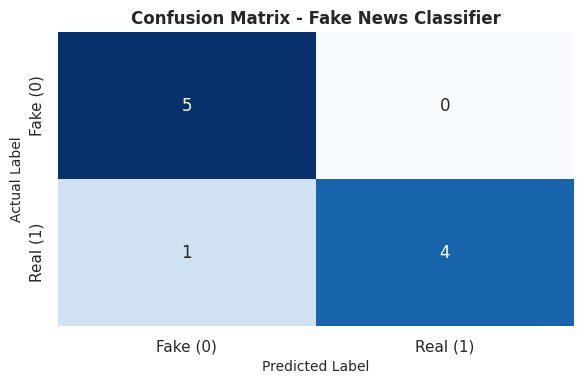

In [23]:
# Visualize model performance using a confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Fake (0)', 'Real (1)'],
            yticklabels=['Fake (0)', 'Real (1)'])
plt.title('Confusion Matrix - Fake News Classifier', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('Actual Label', fontsize=10)
plt.tight_layout()
plt.show()

In [24]:
# Test the trained system on new incoming news headlines/articles
new_articles = [
    "Local city council approves new budget allocations for public park renovations and community centers.",
    "Miracle crystal water proven to instantly reverse aging and cure baldness in three minutes."
]

# Preprocess and vectorize new articles
cleaned_new = [preprocess_text(art) for art in new_articles]
new_tfidf = vectorizer.transform(cleaned_new)
predictions = model.predict(new_tfidf)

print("=== Real-time Article Classification ===")
for art, pred in zip(new_articles, predictions):
    status = "🟢 Genuine News Article" if pred == 1 else "🔴 Fake / Misleading Article"
    print(f"Article: {art}\nClassification: {status}\n")

=== Real-time Article Classification ===
Article: Local city council approves new budget allocations for public park renovations and community centers.
Classification: 🔴 Fake / Misleading Article

Article: Miracle crystal water proven to instantly reverse aging and cure baldness in three minutes.
Classification: 🔴 Fake / Misleading Article

